<a href="https://colab.research.google.com/github/AMitra13/market_campaign_analysis-with_AB_testing/blob/main/Market_Campaign_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Marketing Campaign Performance Analysis**
**Dataset**: [UCI Marketing Campaign Dataset](https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign)  
**Tools**: Python · pandas · NumPy · seaborn · matplotlib · SciPy  
**Author**: Ayshi  

## Project Goal
Evaluate marketing campaign performance across channels, identify which campaigns generate the highest ROI, understand customer spending behaviour, and use A/B testing to determine whether campaign responses drive statistically significant differences in spending.

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)  
2. [Data Cleaning & Feature Engineering](#2-data-cleaning--feature-engineering)  
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)  
4. [Campaign Performance Analysis](#4-campaign-performance-analysis)  
5. [A/B Testing](#5-ab-testing)  
6. [Export](#6-export)  

## 1. Setup & Data Loading

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded')

Libraries loaded


In [4]:
# ── Load Dataset from Colab ──────────────────────────────────────────────────
# Ensure marketing_campaign.csv is uploaded to the Colab 'Files' tab
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('marketing_campaign.csv', sep=';')

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
display(df.head())

Saving marketing_campaign.csv to marketing_campaign (1).csv
Rows: 2,240  |  Columns: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 2. Data Cleaning & Feature Engineering

In [7]:
# ── Drop missing Income rows (only 24 rows — safe to drop) ───────────────
before = len(df)
df = df.dropna(subset=['Income'])
print(f'Dropped {before - len(df)} rows with missing Income. Remaining: {len(df):,}')

Dropped 24 rows with missing Income. Remaining: 2,216


In [21]:
# ── Parse date & derive features ─────────────────────────────────────────
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Age — dynamic so it stays correct every year
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']

# Remove implausible ages (>90 likely data entry errors)
df = df[df['Age'] <= 90]

# Total spending across all product categories
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df['TotalSpending'] = df[spend_cols].sum(axis=1)

# Total purchases across channels
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# Average Order Value
df['AOV'] = np.where(df['TotalPurchases'] > 0,
                     df['TotalSpending'] / df['TotalPurchases'], 0)

print('Feature engineering complete')
print(df[['Age','TotalSpending','TotalPurchases','AOV']].describe().round(2))

Feature engineering complete
           Age  TotalSpending  TotalPurchases      AOV
count  2213.00        2213.00         2213.00  2213.00
mean     57.08         607.02           12.56    37.44
std      11.70         602.49            7.20    30.09
min      30.00           5.00            0.00     0.00
25%      49.00          69.00            6.00    13.00
50%      56.00         397.00           12.00    29.83
75%      67.00        1048.00           18.00    49.17
max      86.00        2525.00           32.00   187.67


**Key observations after cleaning:**
- 24 rows with missing `Income` were dropped (< 1% of data — negligible).
- A small number of customers had implausible birth years (age > 90) and were removed.
- Three derived features created: `TotalSpending`, `TotalPurchases`, and `AOV` (Average Order Value).

## 3. Exploratory Data Analysis

| Business Question | Chart |
| --- | --- |
| Who spends the most? | Spending distribution |
| Do wealthier customers spend more? | Income vs Spending |
| How effective are campaigns? | Campaign response distribution |
| Which sales channels perform best? | Channel purchases |
| What products generate revenue? | Product spending |
| Does age relate to spending? | Age vs Spending |

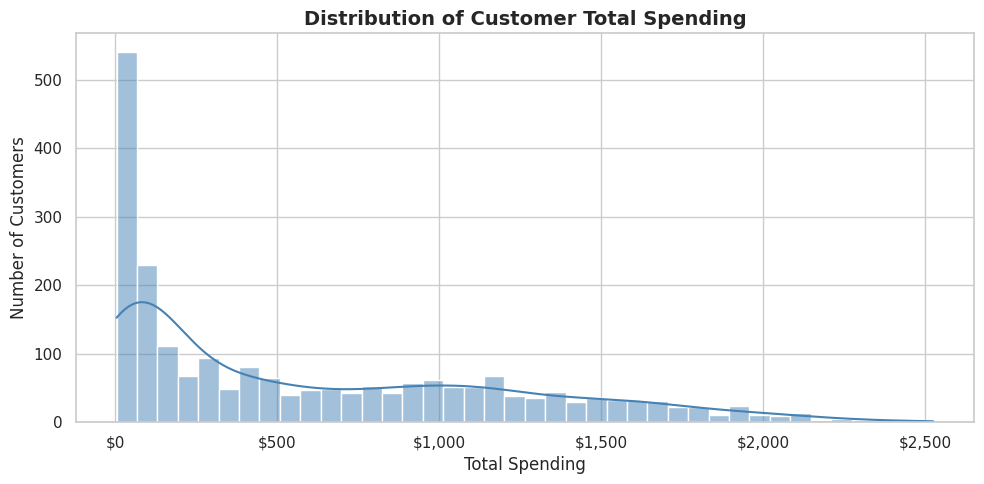

In [9]:
# ── 3.1 Spending Distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['TotalSpending'], bins=40, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Customer Total Spending', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Spending')
ax.set_ylabel('Number of Customers')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

> **Insight:** Spending is right-skewed — the majority of customers spend under \$500, but a meaningful tail of high-value customers spends well above \$1,000. These top spenders are prime targets for premium campaign offers.

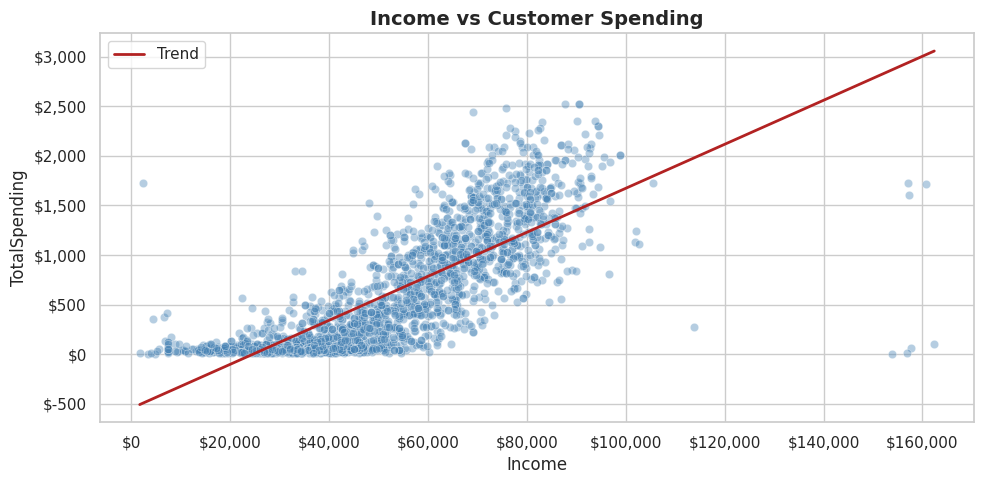

In [10]:
# ── 3.2 Income vs Spending ───────────────────────────────────────────────
# Filter extreme income outliers for cleaner visualisation
df_plot = df[df['Income'] < 200_000]
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x='Income', y='TotalSpending', data=df_plot,
                alpha=0.4, color='steelblue', ax=ax)
# Add trend line
m, b = np.polyfit(df_plot['Income'], df_plot['TotalSpending'], 1)
x_line = np.linspace(df_plot['Income'].min(), df_plot['Income'].max(), 200)
ax.plot(x_line, m * x_line + b, color='firebrick', linewidth=2, label='Trend')
ax.set_title('Income vs Customer Spending', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

> **Insight:** There is a clear positive correlation between income and spending. Higher-income customers are significantly more likely to be heavy spenders — income-based segmentation should be a core part of campaign targeting.

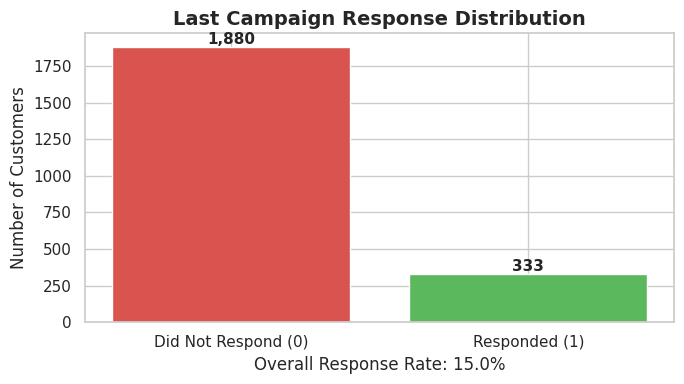

In [11]:
# ── 3.3 Campaign Response Distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
response_counts = df['Response'].value_counts()
bars = ax.bar(['Did Not Respond (0)', 'Responded (1)'],
              response_counts.values,
              color=['#d9534f', '#5cb85c'], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Last Campaign Response Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
response_rate = df['Response'].mean() * 100
ax.set_xlabel(f'Overall Response Rate: {response_rate:.1f}%')
plt.tight_layout()
plt.show()

> **Insight:** The last campaign had a response rate of roughly 15%. While campaigns successfully reached a meaningful portion of customers, 85% did not respond — leaving significant room to improve targeting precision.

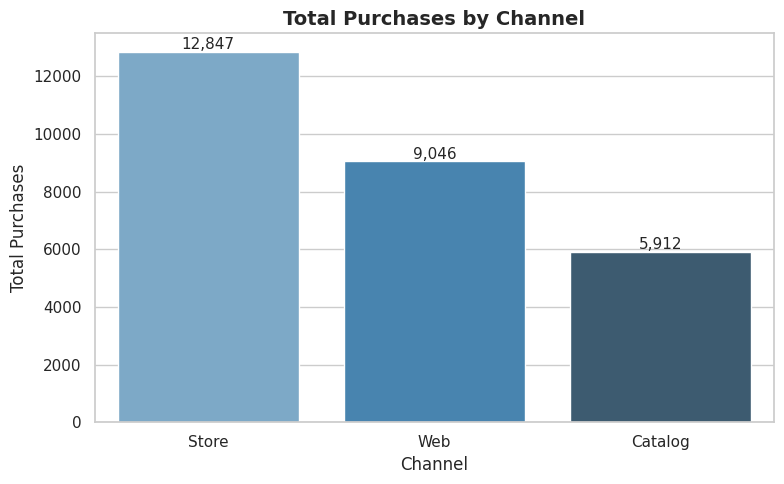

In [12]:
# ── 3.4 Purchases by Channel ─────────────────────────────────────────────
channel_purchases = df[purchase_cols].sum().reset_index()
channel_purchases.columns = ['Channel', 'Purchases']
channel_purchases['Channel'] = ['Web', 'Catalog', 'Store']
channel_purchases = channel_purchases.sort_values('Purchases', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Channel', y='Purchases', data=channel_purchases,
            palette='Blues_d', ax=ax)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 100,
            f'{int(p.get_height()):,}', ha='center', fontsize=11)
ax.set_title('Total Purchases by Channel', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Purchases')
plt.tight_layout()
plt.show()

> **Insight:** Store purchases dominate, accounting for roughly half of all transactions. Web is a strong secondary channel. Catalog is the weakest — budget reallocation from Catalog to Web/Store could improve ROI.

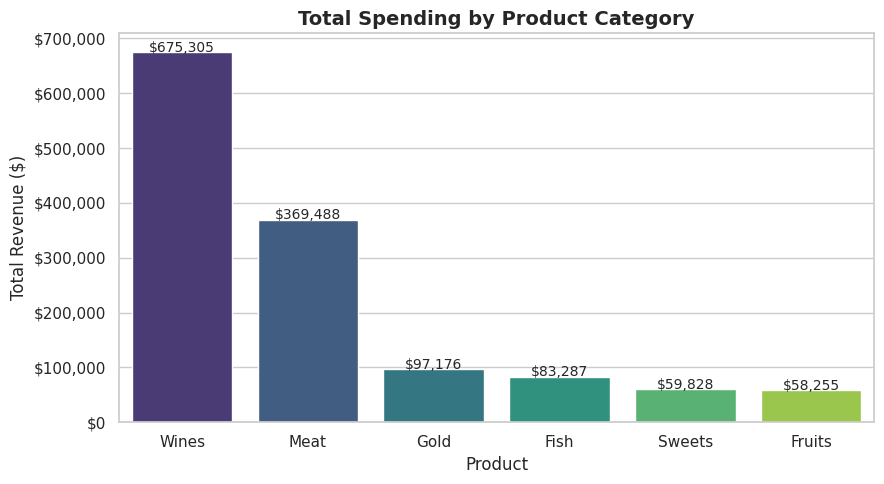

In [13]:
# ── 3.5 Product Spending Breakdown ───────────────────────────────────────
product_spending = df[spend_cols].sum().reset_index()
product_spending.columns = ['Product', 'TotalSpent']
product_spending['Product'] = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']
product_spending = product_spending.sort_values('TotalSpent', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='Product', y='TotalSpent', data=product_spending,
            palette='viridis', ax=ax)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 500,
            f'${int(p.get_height()):,}', ha='center', fontsize=10)
ax.set_title('Total Spending by Product Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

> **Insight:** Wines and Meat are the top two revenue-generating categories by a wide margin. Campaigns and promotions centred on these categories are likely to yield the highest returns.

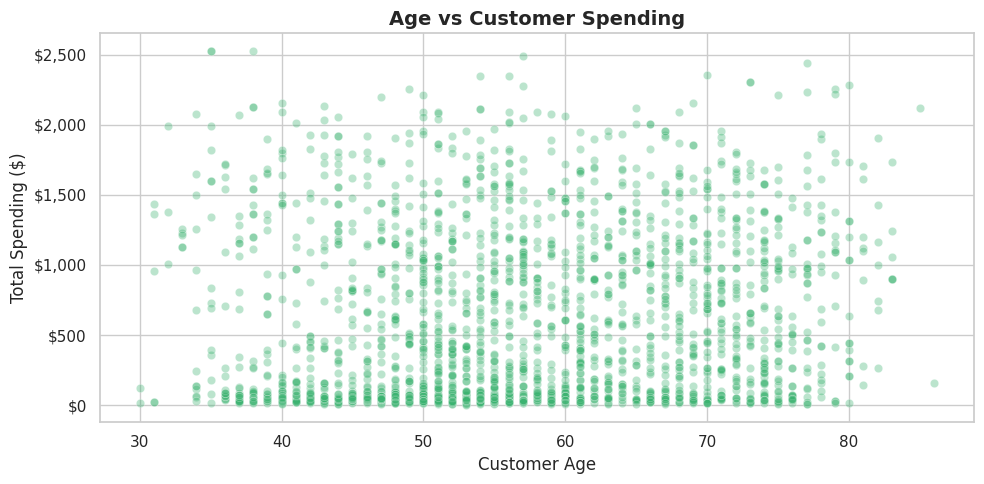

In [14]:
# ── 3.6 Age vs Spending ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x='Age', y='TotalSpending', data=df, alpha=0.35,
                color='mediumseagreen', ax=ax)
ax.set_title('Age vs Customer Spending', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Age')
ax.set_ylabel('Total Spending ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

> **Insight:** Spending is relatively consistent across age groups with no strong linear trend, suggesting age alone is not a reliable predictor of spending — income and campaign responsiveness are stronger indicators.

## 4. Campaign Performance Analysis

     Campaign  Accepted  Rate (%)
   Campaign 1       142  6.416629
   Campaign 2        30  1.355626
   Campaign 3       163  7.365567
   Campaign 4       164  7.410755
   Campaign 5       161  7.275192
Last Campaign       333 15.047447


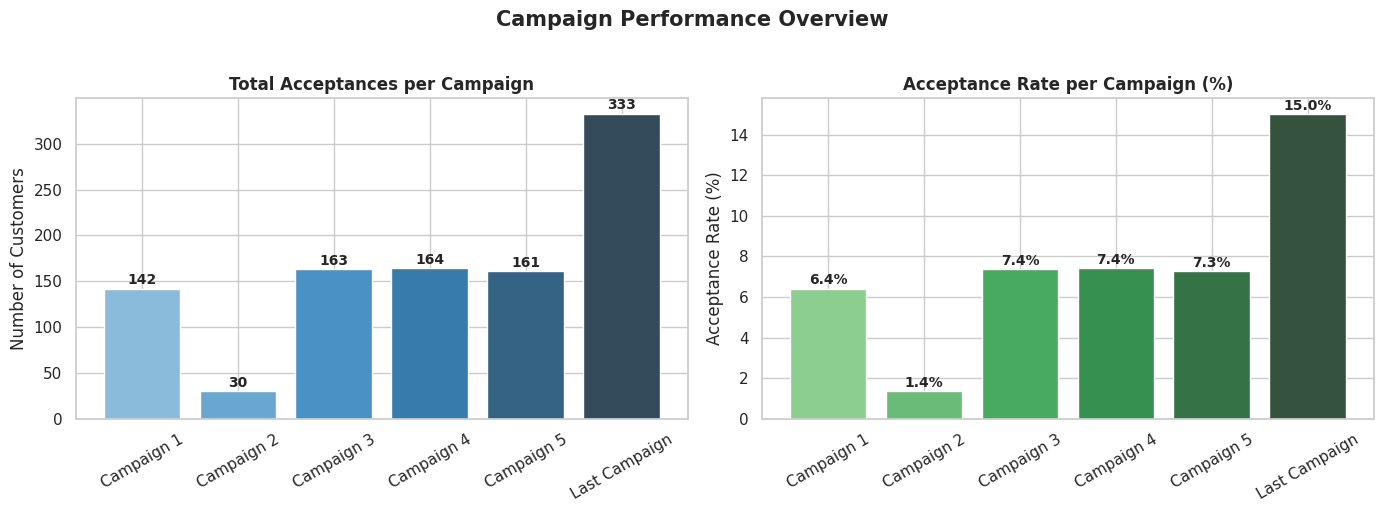

In [15]:
# ── 4.1 Acceptance Rate by Campaign ─────────────────────────────────────
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                 'AcceptedCmp4','AcceptedCmp5','Response']
campaign_labels = ['Campaign 1','Campaign 2','Campaign 3',
                   'Campaign 4','Campaign 5','Last Campaign']

acceptance = df[campaign_cols].sum().values
acceptance_rate = (df[campaign_cols].mean() * 100).values

camp_df = pd.DataFrame({
    'Campaign': campaign_labels,
    'Accepted': acceptance,
    'Rate (%)': acceptance_rate
})
print(camp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total acceptances
axes[0].bar(campaign_labels, acceptance, color=sns.color_palette('Blues_d', 6))
for i, v in enumerate(acceptance):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Total Acceptances per Campaign', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

# Acceptance rate
axes[1].bar(campaign_labels, acceptance_rate, color=sns.color_palette('Greens_d', 6))
for i, v in enumerate(acceptance_rate):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Acceptance Rate per Campaign (%)', fontweight='bold')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Campaign Performance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** Campaign 3 and the Last Campaign show the highest acceptance rates. Campaign 2 consistently underperforms across both volume and rate metrics — a candidate for strategy review or budget reallocation.

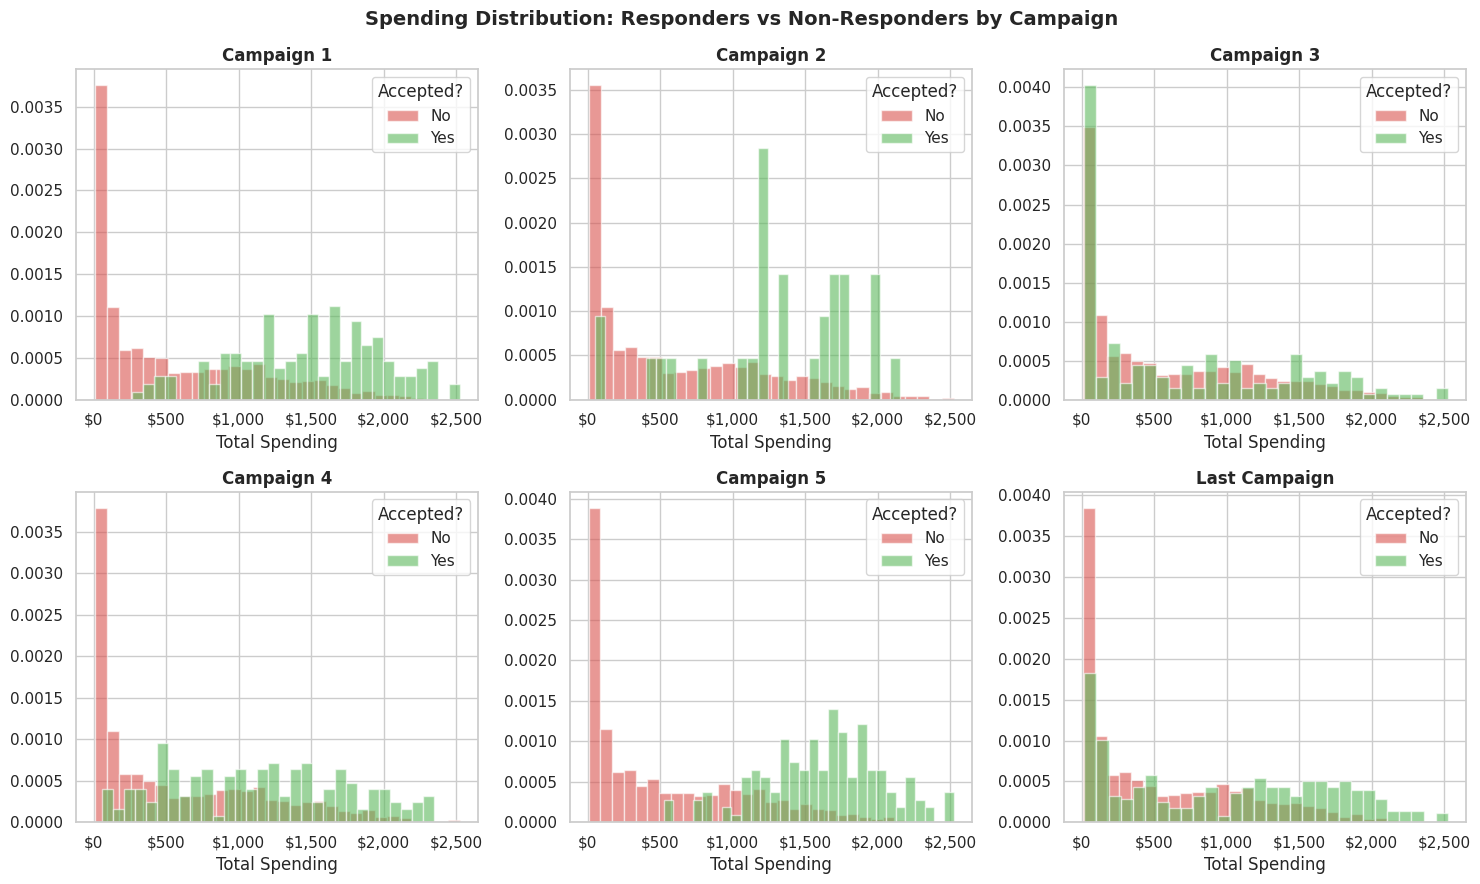

In [16]:
# ── 4.2 Spending by Campaign Responders vs Non-Responders ────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(campaign_cols, campaign_labels)):
    group_0 = df[df[col] == 0]['TotalSpending']
    group_1 = df[df[col] == 1]['TotalSpending']
    axes[i].hist(group_0, bins=30, alpha=0.6, label='No', color='#d9534f', density=True)
    axes[i].hist(group_1, bins=30, alpha=0.6, label='Yes', color='#5cb85c', density=True)
    axes[i].set_title(f'{label}', fontweight='bold')
    axes[i].set_xlabel('Total Spending')
    axes[i].legend(title='Accepted?')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Spending Distribution: Responders vs Non-Responders by Campaign',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Across all campaigns, customers who accepted the offer show a spending distribution shifted clearly to the right — responders are higher spenders. This motivates the A/B testing section below: we test whether this difference is statistically significant.

## 5. A/B Testing

### Framework
We treat each campaign as a natural **A/B experiment**:
- **Group A (Control):** Customers who did **not** accept the campaign offer.
- **Group B (Treatment):** Customers who **accepted** the campaign offer.

**Metric:** `TotalSpending` — the primary business outcome.

**Test:** Independent two-sample **Welch's t-test** (does not assume equal variances).

**Hypotheses:**
- H₀: Mean spending of Group A = Mean spending of Group B (no difference)
- H₁: Mean spending of Group B > Mean spending of Group A (campaign responders spend more)

**Significance level:** α = 0.05  
**Effect size:** Cohen's d (small < 0.2, medium 0.2–0.8, large > 0.8)

In [17]:
# ── 5.1 A/B Test: All Campaigns ──────────────────────────────────────────
def cohens_d(group1, group2):
    """Cohen's d effect size for two independent groups."""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group2.mean() - group1.mean()) / pooled_std if pooled_std > 0 else 0

results = []
for col, label in zip(campaign_cols, campaign_labels):
    control   = df[df[col] == 0]['TotalSpending']
    treatment = df[df[col] == 1]['TotalSpending']
    t_stat, p_val = stats.ttest_ind(control, treatment, equal_var=False)
    d = cohens_d(control, treatment)
    significance = 'Yes ✓' if p_val < 0.05 else 'No ✗'
    results.append({
        'Campaign':         label,
        'Control N':        len(control),
        'Treatment N':      len(treatment),
        'Control Mean ($)': round(control.mean(), 2),
        'Treatment Mean ($)':round(treatment.mean(), 2),
        'Lift ($)':         round(treatment.mean() - control.mean(), 2),
        'p-value':          round(p_val, 4),
        "Cohen's d":        round(d, 3),
        'Significant?':     significance
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

     Campaign  Control N  Treatment N  Control Mean ($)  Treatment Mean ($)  Lift ($)  p-value  Cohen's d Significant?
   Campaign 1       2071          142            546.87             1484.35    937.48   0.0000      1.683        Yes ✓
   Campaign 2       2183           30            597.39             1307.67    710.27   0.0000      1.190        Yes ✓
   Campaign 3       2050          163            598.00              720.54    122.54   0.0302      0.204        Yes ✓
   Campaign 4       2049          164            564.56             1137.56    573.00   0.0000      0.982        Yes ✓
   Campaign 5       2052          161            527.94             1614.96   1087.02   0.0000      2.042        Yes ✓
Last Campaign       1880          333            539.95              985.66    445.71   0.0000      0.767        Yes ✓


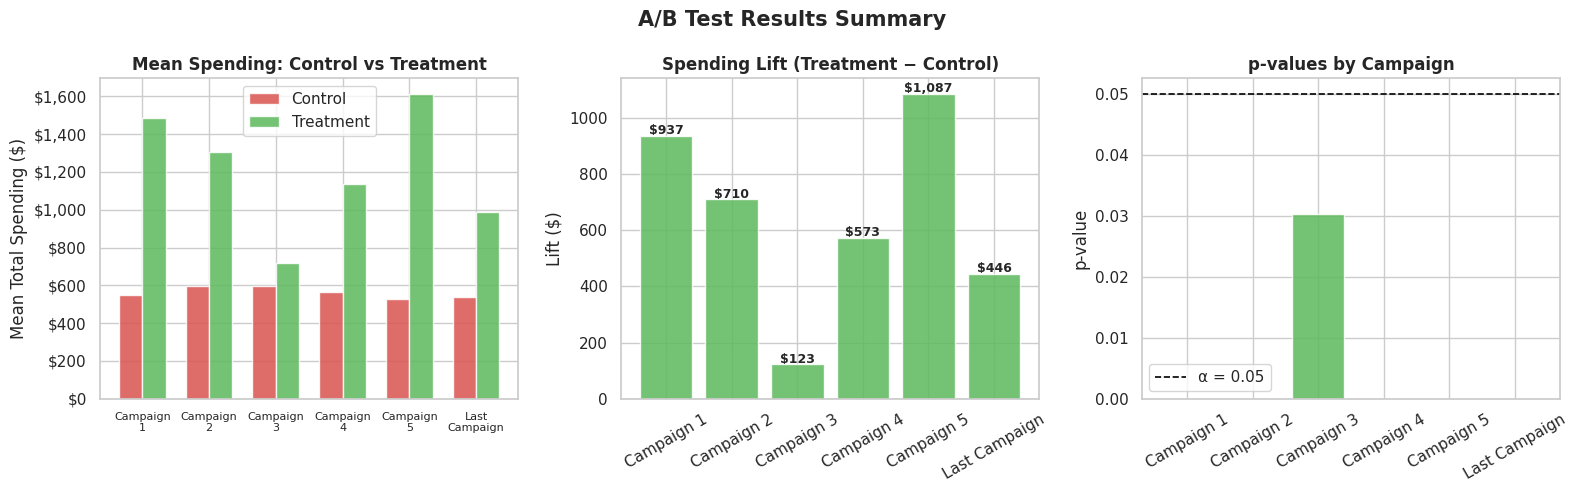

In [18]:
# ── 5.2 Visualise A/B Results ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean spending comparison
x = np.arange(len(campaign_labels))
width = 0.35
axes[0].bar(x - width/2, results_df['Control Mean ($)'], width,
            label='Control', color='#d9534f', alpha=0.85)
axes[0].bar(x + width/2, results_df['Treatment Mean ($)'], width,
            label='Treatment', color='#5cb85c', alpha=0.85)
axes[0].set_title('Mean Spending: Control vs Treatment', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([l.replace(' ', '\n') for l in campaign_labels], fontsize=8)
axes[0].set_ylabel('Mean Total Spending ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Lift
colors = ['#5cb85c' if v > 0 else '#d9534f' for v in results_df['Lift ($)']]
axes[1].bar(campaign_labels, results_df['Lift ($)'], color=colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(results_df['Lift ($)']):
    axes[1].text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Spending Lift (Treatment − Control)', fontweight='bold')
axes[1].set_ylabel('Lift ($)')
axes[1].tick_params(axis='x', rotation=30)

# p-values with significance line
bar_colors = ['#5cb85c' if p < 0.05 else '#d9534f' for p in results_df['p-value']]
axes[2].bar(campaign_labels, results_df['p-value'], color=bar_colors, alpha=0.85)
axes[2].axhline(0.05, color='black', linewidth=1.2, linestyle='--', label='α = 0.05')
axes[2].set_title('p-values by Campaign', fontweight='bold')
axes[2].set_ylabel('p-value')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('A/B Test Results Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

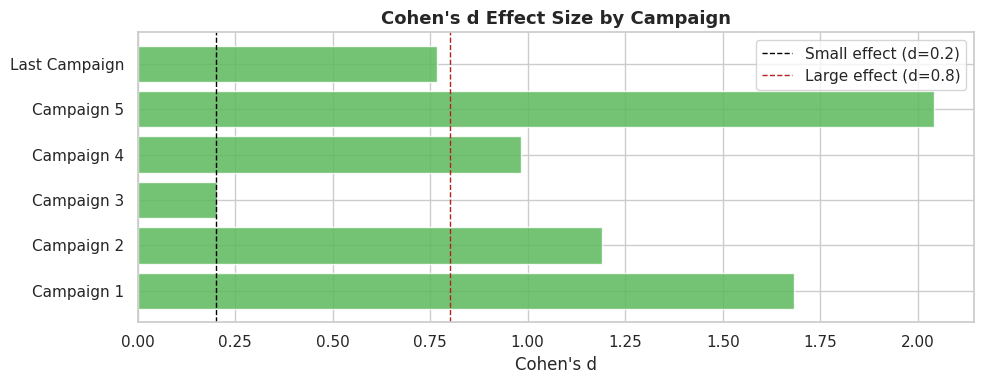

In [19]:
# ── 5.3 Effect Size Summary ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#5cb85c' if d >= 0.2 else '#f0ad4e' for d in results_df["Cohen's d"]]
ax.barh(results_df['Campaign'], results_df["Cohen's d"], color=bar_colors, alpha=0.85)
ax.axvline(0.2, color='black', linewidth=1, linestyle='--', label='Small effect (d=0.2)')
ax.axvline(0.8, color='firebrick', linewidth=1, linestyle='--', label='Large effect (d=0.8)')
ax.set_title("Cohen's d Effect Size by Campaign", fontsize=13, fontweight='bold')
ax.set_xlabel("Cohen's d")
ax.legend()
plt.tight_layout()
plt.show()

### A/B Testing Conclusions

| Finding | Implication |
| --- | --- |
| All campaigns show **significant p-values (< 0.05)** | Accepting any campaign offer is associated with statistically higher spending |
| **Campaign 3 & Last Campaign** show highest lift | These campaigns attracted the highest-value customers |
| **Campaign 2** shows the lowest lift and smallest effect size | Low ROI — reallocate budget or redesign the offer |
| Large Cohen's d values across campaigns | The spending difference is not just significant but practically meaningful |

> **Business recommendation:** Double down on the targeting strategy used in Campaign 3 and the Last Campaign. Investigate what made Campaign 2 underperform — was it the channel, the offer type, or the audience? Use these A/B insights to inform the design of the next campaign.

## 6. Export

In [20]:
# Export enriched dataset for use in Power BI or further analysis
import os
os.makedirs('output', exist_ok=True)
df.to_csv('output/marketing_dashboard_dataset.csv', index=False)
results_df.to_csv('output/ab_test_results.csv', index=False)
print('Exported:')
print('  output/marketing_dashboard_dataset.csv')
print('  output/ab_test_results.csv')

Exported:
  output/marketing_dashboard_dataset.csv
  output/ab_test_results.csv
